# Trabalho 1 — PLN com Pokémon FireRed

**Objetivo:** construir e analisar um corpus textual dos 151 Pokémon da Pokédex de Kanto, com recorte de dados para **Pokémon FireRed**, usando somente técnicas trabalhadas nas aulas até agora.


In [1]:
from pathlib import Path
from collections import Counter
from datetime import datetime
import concurrent.futures
import hashlib
import json
import logging
import re
import unicodedata
import time

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests

from google.colab import drive

from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from scipy.sparse import save_npz
from sklearn.feature_extraction.text import CountVectorizer


drive.mount("/content/drive")

base_path = Path(
    "/content/drive/MyDrive/IFSP-ADS/ultimo_periodo/tc_2/avaliacao/corpus"
)

root = base_path / "corpus_data_firered"

RAW_DIR = root / "raw_data"
PROCESSED_DIR = root / "processed_data" / "txt"
METADATA_DIR = root / "metadata"
ARTIFACTS_DIR = root / "artifacts"
RESULTS_DIR = root / "results"
LOG_DIR = root / "logs" / "trabalho_1"

for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    METADATA_DIR,
    ARTIFACTS_DIR,
    RESULTS_DIR,
    LOG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:", root)

Mounted at /content/drive
Estrutura criada em: /content/drive/MyDrive/IFSP-ADS/ultimo_periodo/tc_2/avaliacao/corpus/corpus_data_firered


## Logging da execução

O log registra as principais etapas do processamento e fica salvo no Google Drive.



In [2]:
LOG_FILE = LOG_DIR / "execution.log"

logger = logging.getLogger("pokemon_corpus")
logger.setLevel(logging.INFO)
logger.propagate = False

logger.handlers.clear()

formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

file_handler = logging.FileHandler(
    LOG_FILE,
    mode="w",
    encoding="utf-8"
)
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(formatter)

console_handler = logging.StreamHandler()
console_handler.setLevel(logging.WARNING)
console_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info("Início da execução do Trabalho 1")
logger.info("Diretório raiz: %s", root)
logger.info("Arquivo de log: %s", LOG_FILE)

print("Logger configurado.")
print("Arquivo de log:", LOG_FILE)

Logger configurado.
Arquivo de log: /content/drive/MyDrive/IFSP-ADS/ultimo_periodo/tc_2/avaliacao/corpus/corpus_data_firered/logs/trabalho_1/execution.log


## Ambiente e recursos do NLTK

O pré-processamento usa recursos do NLTK:
tokenização, stopwords, POS tagging como apoio à lematização e WordNetLemmatizer.

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

STOPWORDS_EN = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

logger.info("Recursos do NLTK carregados")

print("Recursos do NLTK prontos.")

Recursos do NLTK prontos.


In [4]:
print("Stopwords em inglês:", len(STOPWORDS_EN))

Stopwords em inglês: 198


## Coleta do corpus

O corpus foi construído especificamente para este trabalho a partir da **PokéAPI**, utilizada como fonte de dados estruturados.

O recorte contém os **151 Pokémon da Pokédex de Kanto**, com foco em informações compatíveis com **Pokémon FireRed**. Cada Pokémon corresponde a um documento do corpus.

A coleta automatizada salva os dados brutos em JSON antes de qualquer transformação. Essa separação permite auditoria, reprocessamento e reprodução do experimento.

### Origem e características do corpus

O corpus foi construído a partir da PokéAPI, com 151 documentos, um para cada Pokémon de Kanto (IDs 1–151). Os dados são predominantemente em inglês e combinam descrições textuais, atributos estruturados e metadados numéricos.
Quando disponíveis, foram priorizados dados específicos de FireRed; quando a API agrupa versões, foi utilizado o grupo firered-leafgreen.
Os dados brutos foram preservados separadamente dos documentos processados, permitindo auditoria e reprocessamento sem nova coleta.

### Critérios de inclusão e exclusão

Foram incluídos os 151 Pokémon de Kanto (IDs 1–151), com descrições em inglês, tipos compatíveis com a Geração III, golpes de FireRed/LeafGreen, linha evolutiva e metadados gerais.
Na representação textual foram utilizados nome, tipos, habitat, golpes, evolução e descrição. Atributos numéricos, como altura, peso, capture_rate e encontros, foram mantidos apenas como metadados para preservar essas informações sem incorporá-las ao Bag of Words.

In [5]:
BASE_URL = "https://pokeapi.co/api/v2"
TIMEOUT = 30

session = requests.Session()
session.headers.update({
    "User-Agent": "IFSP-PLN-Pokemon-Corpus/1.0"
})

def fetch_json(url, attempts=3):
    last_error = None

    for attempt in range(attempts):
        try:
            response = session.get(url, timeout=TIMEOUT)

            response.raise_for_status()

            return response.json()

        except Exception as exc:

            last_error = exc

            time.sleep(1 + attempt)

    raise last_error


def collect_pokemon(pokemon_id):
    output = RAW_DIR / f"{pokemon_id:03d}.json"

    if output.exists():

        return "cached"

    pokemon = fetch_json(f"{BASE_URL}/pokemon/{pokemon_id}")

    species = fetch_json(f"{BASE_URL}/pokemon-species/{pokemon_id}")

    evolution_url = (
        species.get("evolution_chain", {}) or {}
    ).get("url")

    evolution_chain = (
        fetch_json(evolution_url)

        if evolution_url else None
    )

    encounters = fetch_json(
        f"{BASE_URL}/pokemon/{pokemon_id}/encounters"
    )

    bundle = {
        "id": pokemon_id,

        "pokemon": pokemon,

        "species": species,

        "evolution_chain": evolution_chain,

        "encounters": encounters,
    }

    output.write_text(
        json.dumps(bundle, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    return "downloaded"

In [6]:
collection = []

for pokemon_id in range(1, 152):
    try:
        status = collect_pokemon(pokemon_id)
        collection.append({
            "id": pokemon_id,
            "status": status,
            "error": None
        })
    except Exception as exc:
        collection.append({
            "id": pokemon_id,
            "status": "error",
            "error": str(exc)
        })

df_collection = pd.DataFrame(collection)
display(df_collection["status"].value_counts().to_frame("count"))

errors = df_collection[df_collection["status"] == "error"]

print("Erros:", len(errors))

logger.info(
    "Coleta concluída | total=%s | erros=%s",
    len(df_collection),
    int((df_collection["status"] == "error").sum())
)


,count
status,
cached,151


Erros: 0


## Validação dos dados brutos

Antes do pré-processamento, verificamos se os 151 arquivos existem e podem ser lidos.

In [7]:
raw_files = sorted(RAW_DIR.glob("*.json"))

raw_documents = []
read_errors = []

for path in raw_files:
    try:
        bundle = json.loads(path.read_text(encoding="utf-8"))
        raw_documents.append({
            "source_file": path.name,
            "bundle": bundle
        })
    except Exception as exc:
        read_errors.append({
            "source_file": path.name,
            "error": str(exc)
        })

print("Arquivos brutos:", len(raw_files))
print("Erros de leitura:", len(read_errors))

if read_errors:
    display(pd.DataFrame(read_errors))

Arquivos brutos: 151
Erros de leitura: 0


## Recorte para FireRed

A PokéAPI nem sempre separa todos os atributos por jogo.

Neste trabalho:
- descrição: `firered`;
- golpes: grupo `firered-leafgreen`;
- encontros: `firered`;
- tipos: tipos válidos na Geração III;
- altura, peso, habitat e capture rate: ficam apenas como metadados.

In [8]:
FIRERED_VERSION = "firered"
FIRERED_VERSION_GROUP = "firered-leafgreen"
TARGET_GENERATION = 3

GENERATION_NUMBER = {
    "generation-i": 1,
    "generation-ii": 2,
    "generation-iii": 3,
    "generation-iv": 4,
    "generation-v": 5,
    "generation-vi": 6,
    "generation-vii": 7,
    "generation-viii": 8,
    "generation-ix": 9,
}


def get_types_for_generation(pokemon, target_generation=TARGET_GENERATION):
    current_types = sorted(
        pokemon.get("types", []),
        key=lambda item: item.get("slot", 99)
    )

    candidates = []

    for past in pokemon.get("past_types", []):

        generation_name = past.get("generation", {}).get("name", "")

        generation_number = GENERATION_NUMBER.get(generation_name)

        if (
            generation_number is not None
            and generation_number >= target_generation
        ):
            candidates.append((
                generation_number,
                sorted(
                    past.get("types", []),
                    key=lambda item: item.get("slot", 99)
                )
            ))

    selected = (
        min(candidates, key=lambda item: item[0])[1]
        if candidates
        else current_types
    )

    return [
        item["type"]["name"]
        for item in selected
        if item.get("type", {}).get("name")
    ]


def parse_evolution_chain(node):
    result = []

    if not node:
        return result

    species = node.get("species", {})
    name = species.get("name", "")
    url = species.get("url", "")

    species_id = None
    if url:
        try:
            species_id = int(url.rstrip("/").split("/")[-1])
        except ValueError:
            pass

    if name and species_id is not None and 1 <= species_id <= 151:
        result.append(name)

    for child in node.get("evolves_to", []):
        result.extend(parse_evolution_chain(child))

    return result

## Pré-processamento

### O que foi normalizado

Foi utilizado **NFC**, lowercase e padronização de espaços. A limpeza continua leve porque a PokéAPI já entrega textos estruturados.

### Onde lematização foi utilizada

A lematização é aplicada **somente à descrição textual do FireRed**.

Para melhorar a escolha do lema, foi utilizado POS tagging apenas como apoio interno ao WordNetLemmatizer.

Nomes de Pokémon, tipos e golpes são preservados como termos do domínio.

In [9]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = text.replace("\n", " ").replace("\f", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_domain_phrase(text):
    text = normalize_text(text)
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_description(text, remove_stopwords=True):
    normalized = normalize_text(text)

    tokens = [
        token.lower()
        for token in word_tokenize(normalized)
        if token.isalpha()
    ]

    if remove_stopwords:
        tokens = [
            token
            for token in tokens
            if token not in STOPWORDS_EN
        ]

    tagged_tokens = pos_tag(tokens)

    lemmas = [
        LEMMATIZER.lemmatize(
            token,
            penn_to_wordnet(tag)
        )
        for token, tag in tagged_tokens
    ]

    return lemmas

## Stopwords

stopwords foram removidas **da descrição** porque essa parte é linguagem natural e contém muitos artigos, preposições e auxiliares.

Nos campos estruturados nada foi removido: nomes, tipos e golpes são informação do domínio.

Para a análise de N-grams, foi utilizada a descrição **antes da remoção de stopwords**, porque retirar palavras pode criar pares que nunca foram vizinhos no texto original.

## Construção dos documentos

O documento processado combina:

- nome;
- tipos;
- habitat;
- linha evolutiva;
- golpes de FireRed/LeafGreen;
- lemas da descrição do FireRed.

Os valores numéricos permanecem nos metadados e não entram no Bag of Words.

In [10]:
def build_record(bundle, source_file):
    pokemon = bundle["pokemon"]
    species = bundle["species"]
    evolution_raw = bundle.get("evolution_chain") or {}
    encounters = bundle.get("encounters") or []

    pokemon_id = int(bundle["id"])
    api_name = pokemon["name"]

    types = get_types_for_generation(pokemon)
    primary_type = types[0] if types else None
    secondary_type = types[1] if len(types) > 1 else None

    moves = []
    for move_item in pokemon.get("moves", []):
        include = any(
            detail.get("version_group", {}).get("name")
            == FIRERED_VERSION_GROUP
            for detail in move_item.get("version_group_details", [])
        )

        if include:
            move_name = move_item["move"]["name"].replace("-", " ")
            if move_name not in moves:
                moves.append(move_name)

    flavor_text = ""
    flavor_fallback = False

    for entry in species.get("flavor_text_entries", []):
        if (
            entry.get("language", {}).get("name") == "en"
            and entry.get("version", {}).get("name") == FIRERED_VERSION
        ):
            flavor_text = entry.get("flavor_text", "")
            break

    if not flavor_text:
        for entry in species.get("flavor_text_entries", []):
            if entry.get("language", {}).get("name") == "en":
                flavor_text = entry.get("flavor_text", "")
                flavor_fallback = True
                break

    habitat = (
        species.get("habitat", {}).get("name", "unknown")
        if species.get("habitat")
        else "unknown"
    )

    evolution_line = parse_evolution_chain(
        evolution_raw.get("chain", {})
    )

    encounter_areas = []
    for encounter in encounters:
        has_firered = any(
            detail.get("version", {}).get("name") == FIRERED_VERSION
            for detail in encounter.get("version_details", [])
        )

        if has_firered:
            location = (
                encounter.get("location_area", {})
                .get("name", "")
                .replace("-", " ")
            )
            if location and location not in encounter_areas:
                encounter_areas.append(location)

    structured_phrases = (
        [api_name]
        + types
        + [habitat]
        + evolution_line
        + moves
    )

    structured_tokens = []
    for phrase in structured_phrases:
        structured_tokens.extend(
            normalize_domain_phrase(phrase).split()
        )

    description_lemmas = preprocess_description(
        flavor_text,
        remove_stopwords=True
    )

    processed_tokens = structured_tokens + description_lemmas
    processed_text = " ".join(processed_tokens)

    description_for_ngrams = normalize_domain_phrase(flavor_text)

    source_text = " ".join([
        normalize_domain_phrase(api_name),
        normalize_domain_phrase(" ".join(types)),
        normalize_domain_phrase(habitat),
        normalize_domain_phrase(" ".join(evolution_line)),
        normalize_domain_phrase(" ".join(moves)),
        normalize_domain_phrase(flavor_text),
    ])

    return {
        "id": pokemon_id,
        "name": api_name.replace("-", " ").title(),
        "api_name": api_name,
        "source_file": source_file,
        "primary_type": primary_type,
        "secondary_type": secondary_type,
        "height_m": pokemon.get("height", 0) / 10,
        "weight_kg": pokemon.get("weight", 0) / 10,
        "habitat": habitat,
        "capture_rate": species.get("capture_rate"),
        "moves": moves,
        "moves_count": len(moves),
        "evolution_line": evolution_line,
        "encounter_areas": encounter_areas,
        "description": flavor_text,
        "description_for_ngrams": description_for_ngrams,
        "source_text": source_text,
        "processed_text": processed_text,
        "description_fallback": flavor_fallback,
    }

In [11]:
records = []
build_errors = []

for item in raw_documents:
    try:
        records.append(
            build_record(
                item["bundle"],
                item["source_file"]
            )
        )
    except Exception as exc:
        build_errors.append({
            "source_file": item["source_file"],
            "error": str(exc)
        })

print("Documentos construídos:", len(records))
print("Erros:", len(build_errors))

if build_errors:
    display(pd.DataFrame(build_errors))

logger.info(
    "Construção dos documentos concluída | documentos=%s | erros=%s",
    len(records),
    len(build_errors)
)


Documentos construídos: 151
Erros: 0


## Duplicatas e salvamento

Usamos hash apenas para detectar documentos exatamente iguais.  
O hash não mede semelhança textual.

In [12]:
def sha256_text(text):
    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


for record in records:
    record["processed_hash"] = sha256_text(
        record["processed_text"]
    )

hash_counts = Counter(
    record["processed_hash"]
    for record in records
)

duplicate_hashes = {
    h for h, count in hash_counts.items()
    if count > 1
}

print("Grupos de duplicatas exatas:", len(duplicate_hashes))

Grupos de duplicatas exatas: 0


In [13]:
for path in PROCESSED_DIR.glob("*.txt"):
    path.unlink()

for record in records:
    (
        PROCESSED_DIR / f"pokemon_{record['id']:03d}.txt"
    ).write_text(
        record["processed_text"],
        encoding="utf-8"
    )

metadata = pd.DataFrame([
    {
        "id": r["id"],
        "name": r["name"],
        "api_name": r["api_name"],
        "primary_type": r["primary_type"],
        "secondary_type": r["secondary_type"],
        "habitat": r["habitat"],
        "height_m": r["height_m"],
        "weight_kg": r["weight_kg"],
        "capture_rate": r["capture_rate"],
        "moves_count": r["moves_count"],
        "encounter_area_count": len(r["encounter_areas"]),
        "processed_tokens": len(r["processed_text"].split()),
        "processed_hash": r["processed_hash"],
        "description_fallback": r["description_fallback"],
    }
    for r in records
])

metadata.to_csv(
    METADATA_DIR / "pokemon_metadata_firered.csv",
    index=False,
    encoding="utf-8"
)

metadata.to_json(
    METADATA_DIR / "pokemon_metadata_firered.json",
    orient="records",
    force_ascii=False,
    indent=2
)

display(metadata.head())

,id,name,api_name,primary_type,secondary_type,habitat,height_m,weight_kg,capture_rate,moves_count,encounter_area_count,processed_tokens,processed_hash,description_fallback
0,1,Bulbasaur,bulbasaur,grass,poison,grassland,0.7,6.9,45,42,1,83,e0b55d667c338188291ce02135f9f637568bb73f5550dc...,False
1,2,Ivysaur,ivysaur,grass,poison,grassland,1.0,13.0,45,34,0,69,4e4b110ea15eba3106f24aa86e0b6ca4675068af548756...,False
2,3,Venusaur,venusaur,grass,poison,grassland,2.0,100.0,45,38,0,73,fc58f0a4a4e11efac417e906791ab8c79951ac50f89f34...,False
3,4,Charmander,charmander,fire,None,mountain,0.6,8.5,45,48,1,91,1754c77eefa527cfae09b23380c7dfa89b48dba0576c39...,False
4,5,Charmeleon,charmeleon,fire,None,mountain,1.1,19.0,45,42,0,79,13b49e2a1e92e1bea3be8c000d6095c2933c64f4d1c93d...,False


## Validação e estatísticas

Esperamos exatamente 151 documentos, sem IDs ou nomes duplicados e sem textos vazios.

In [14]:
documents = [record["processed_text"] for record in records]

validation = {
    "arquivos_brutos": len(raw_files),
    "documentos_processados": len(documents),
    "ids_duplicados": int(metadata["id"].duplicated().sum()),
    "nomes_duplicados": int(metadata["api_name"].duplicated().sum()),
    "grupos_textos_duplicados": len(duplicate_hashes),
    "documentos_vazios": sum(not doc.strip() for doc in documents),
    "erros_construcao": len(build_errors),
}

display(
    pd.DataFrame(
        validation.items(),
        columns=["verificacao", "valor"]
    )
)

assert len(raw_files) == 151
assert len(documents) == 151
assert validation["ids_duplicados"] == 0
assert validation["nomes_duplicados"] == 0
assert validation["documentos_vazios"] == 0
assert validation["erros_construcao"] == 0

logger.info(
    "Validação concluída com sucesso | documentos=%s",
    len(documents)
)


,verificacao,valor
0,arquivos_brutos,151
1,documentos_processados,151
2,ids_duplicados,0
3,nomes_duplicados,0
4,grupos_textos_duplicados,0
5,documentos_vazios,0
6,erros_construcao,0


In [15]:
all_tokens = [
    token
    for document in documents
    for token in document.split()
]

document_lengths = [
    len(document.split())
    for document in documents
]

summary = pd.DataFrame({
    "metrica": [
        "documentos",
        "tokens",
        "vocabulario",
        "media_tokens_documento",
        "menor_documento",
        "maior_documento",
    ],
    "valor": [
        len(documents),
        len(all_tokens),
        len(set(all_tokens)),
        round(float(np.mean(document_lengths)), 2),
        min(document_lengths),
        max(document_lengths),
    ]
})

display(summary)

,metrica,valor
0,documentos,151.00
1,tokens,11093.00
2,vocabulario,1219.00
3,media_tokens_documento,73.46
4,menor_documento,11.00
5,maior_documento,126.00


## Caracterização do corpus

Os tipos dos Pokémon são utilizados apenas para descrever a distribuição do corpus, e não como classes de uma tarefa de classificação.
Essa distribuição permite identificar categorias mais ou menos frequentes e ajuda a interpretar a avaliação, já que consultas associadas a tipos mais comuns tendem a possuir conjuntos de relevância maiores.

In [16]:
type_distribution = (
    metadata["primary_type"]
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="quantidade")
)

display(type_distribution)

,tipo,quantidade
0,water,28
1,normal,24
2,poison,14
3,grass,12
4,fire,12
5,bug,12
6,electric,9
7,rock,9
8,psychic,8
9,ground,8


# Bag of Words

Cada coluna representa um termo do vocabulário e cada linha representa um Pokémon. O valor da célula é a frequência bruta daquele termo no documento.

In [17]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(documents)
bow_terms = bow_vectorizer.get_feature_names_out()

print("Dimensão da matriz:", bow_matrix.shape)
print("Documentos:", bow_matrix.shape[0])
print("Features:", bow_matrix.shape[1])
print("Valores não zero:", bow_matrix.nnz)

joblib.dump(
    bow_vectorizer,
    ARTIFACTS_DIR / "bow_vectorizer.joblib"
)

save_npz(
    ARTIFACTS_DIR / "bow_matrix.npz",
    bow_matrix
)

logger.info(
    "Bag of Words criado | shape=%s | vocabulario=%s",
    bow_matrix.shape,
    len(bow_terms)
)


Dimensão da matriz: (151, 1214)
Documentos: 151
Features: 1214
Valores não zero: 9727


# N-grams

Os N-grams são utilizados como uma análise exploratória do contexto local presente nas descrições.

In [18]:
def tokenize_for_ngrams(text):
    return re.findall(
        r"\b[a-z]+\b",
        normalize_text(text)
    )


def generate_ngrams(text, n):
    tokens = tokenize_for_ngrams(text)

    return [
        " ".join(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]

In [19]:
ngram_stats = []

for n in [1, 2, 3]:
    features = []

    for record in records:
        features.extend(
            generate_ngrams(
                record["description_for_ngrams"],
                n
            )
        )

    ngram_stats.append({
        "n": n,
        "ocorrencias": len(features),
        "features_distintas": len(set(features))
    })

df_ngram_stats = pd.DataFrame(ngram_stats)
display(df_ngram_stats)

,n,ocorrencias,features_distintas
0,1,2844,979
1,2,2693,2156
2,3,2542,2415


# Análise do corpus por busca textual

Como abordagem de análise do corpus, foi realizado um experimento simples de busca textual por palavras-chave utilizando a representação Bag of Words.


Com o Bag of Words, a busca verifica quais termos da consulta estão no vocabulário e recupera documentos que contêm **todos os termos conhecidos da consulta**.

A soma das frequências é usada apenas para ordenar os resultados exibidos.

In [20]:
vocabulary = bow_vectorizer.vocabulary_

def preprocess_query(query):
    query = normalize_domain_phrase(query)

    tokens = [
        token.lower()
        for token in word_tokenize(query)
        if token.isalpha()
        and token.lower() not in STOPWORDS_EN
    ]

    tagged_tokens = pos_tag(tokens)

    return [
        LEMMATIZER.lemmatize(token, penn_to_wordnet(tag))
        for token, tag in tagged_tokens
    ]


def search_bow(query):
    query_tokens = preprocess_query(query)

    known_terms = [
        term for term in query_tokens
        if term in vocabulary
    ]

    if not known_terms:
        return pd.DataFrame(
            columns=[
                "id", "name",
                "termos_encontrados",
                "frequencia_total"
            ]
        )

    indices = [
        vocabulary[term]
        for term in known_terms
    ]

    submatrix = bow_matrix[:, indices]

    matched_terms = np.asarray(
        (submatrix > 0).sum(axis=1)
    ).ravel()

    frequency_score = np.asarray(
        submatrix.sum(axis=1)
    ).ravel()

    mask = matched_terms == len(indices)

    result = metadata.loc[
        mask,
        ["id", "name"]
    ].copy()

    result["termos_encontrados"] = matched_terms[mask]
    result["frequencia_total"] = frequency_score[mask]

    return (
        result
        .sort_values(
            ["frequencia_total", "id"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

In [21]:
display(search_bow("fire flying"))
display(search_bow("surf").head(10))
display(search_bow("solar beam").head(10))

,id,name,termos_encontrados,frequencia_total
0,6,Charizard,2,5
1,146,Moltres,2,5
2,142,Aerodactyl,2,3
3,149,Dragonite,2,3
4,148,Dragonair,2,2
5,151,Mew,2,2


,id,name,termos_encontrados,frequencia_total
0,7,Squirtle,1,1
1,8,Wartortle,1,1
2,9,Blastoise,1,1
3,31,Nidoqueen,1,1
4,34,Nidoking,1,1
5,54,Psyduck,1,1
6,55,Golduck,1,1
7,60,Poliwag,1,1
8,61,Poliwhirl,1,1
9,62,Poliwrath,1,1


,id,name,termos_encontrados,frequencia_total
0,36,Clefable,2,4
1,40,Wigglytuff,2,4
2,48,Venonat,2,4
3,108,Lickitung,2,4
4,113,Chansey,2,4
5,115,Kangaskhan,2,4
6,128,Tauros,2,4
7,137,Porygon,2,4
8,143,Snorlax,2,4
9,150,Mewtwo,2,4


## Baseline: busca literal

A abordagem de referência é uma busca literal pela sequência completa utilizada na consulta de teste.

Ela foi escolhida como baseline porque:
- é simples e fácil de reproduzir
- não depende de representação vetorial
- permite uma comparação com a representação Bag of Words.


In [22]:
def search_literal(query):
    normalized_query = normalize_domain_phrase(query)

    if not normalized_query:
        return pd.DataFrame(
            columns=["id", "name", "ocorrencias"]
        )

    rows = []

    for record in records:
        count = len(
            re.findall(
                re.escape(normalized_query),
                record["source_text"]
            )
        )

        if count > 0:
            rows.append({
                "id": record["id"],
                "name": record["name"],
                "ocorrencias": count
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["ocorrencias", "id"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
        if rows
        else pd.DataFrame(
            columns=["id", "name", "ocorrencias"]
        )
    )

# Avaliação

As consultas foram escolhidas porque possuem uma referência objetiva nos metadados: tipo ou golpe.

Foram utilizados:
- **Precisão:** entre os recuperados, quantos são relevantes;
- **Recall:** entre todos os relevantes, quantos foram recuperados;
- **F1:** equilíbrio entre precisão e recall.

In [23]:
def has_type(row, pokemon_type):
    pokemon_type = pokemon_type.lower()

    return (
        str(row.get("primary_type", "")).lower() == pokemon_type
        or str(row.get("secondary_type", "")).lower() == pokemon_type
    )


def relevant_by_type(pokemon_type):
    return set(
        metadata.loc[
            metadata.apply(
                lambda row: has_type(row, pokemon_type),
                axis=1
            ),
            "id"
        ].astype(int)
    )


def relevant_by_types(types):
    return set(
        metadata.loc[
            metadata.apply(
                lambda row: all(
                    has_type(row, t)
                    for t in types
                ),
                axis=1
            ),
            "id"
        ].astype(int)
    )


def relevant_by_move(move_name):
    target = normalize_domain_phrase(move_name)

    return {
        record["id"]
        for record in records
        if target in {
            normalize_domain_phrase(move)
            for move in record["moves"]
        }
    }

In [24]:
evaluation_queries = [
    {
        "query": "fire",
        "relevant_ids": relevant_by_type("fire")
    },
    {
        "query": "water",
        "relevant_ids": relevant_by_type("water")
    },
    {
        "query": "fire flying",
        "relevant_ids": relevant_by_types(["fire", "flying"])
    },
    {
        "query": "rock ground",
        "relevant_ids": relevant_by_types(["rock", "ground"])
    },
    {
        "query": "surf",
        "relevant_ids": relevant_by_move("surf")
    },
    {
        "query": "solar beam",
        "relevant_ids": relevant_by_move("solar beam")
    },
]

print("Consultas:", len(evaluation_queries))

Consultas: 6


In [25]:
def precision_recall_f1(retrieved_ids, relevant_ids):
    retrieved_ids = set(retrieved_ids)
    relevant_ids = set(relevant_ids)

    hits = len(retrieved_ids & relevant_ids)

    precision = (
        hits / len(retrieved_ids)
        if retrieved_ids else 0.0
    )

    recall = (
        hits / len(relevant_ids)
        if relevant_ids else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return precision, recall, f1


def evaluate_search(search_function, method_name):
    rows = []

    for item in evaluation_queries:
        result = search_function(item["query"])

        retrieved_ids = (
            result["id"].astype(int).tolist()
            if not result.empty
            else []
        )

        precision, recall, f1 = precision_recall_f1(
            retrieved_ids,
            item["relevant_ids"]
        )

        rows.append({
            "metodo": method_name,
            "query": item["query"],
            "relevantes": len(item["relevant_ids"]),
            "recuperados": len(retrieved_ids),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(rows)


evaluation = pd.concat([
    evaluate_search(
        search_literal,
        "Baseline - busca literal"
    ),
    evaluate_search(
        search_bow,
        "Bag of Words"
    ),
], ignore_index=True)

display(evaluation)

,metodo,query,relevantes,recuperados,precision,recall,f1
0,Baseline - busca literal,fire,12,49,0.244898,1.000000,0.393443
1,Baseline - busca literal,water,32,56,0.571429,1.000000,0.727273
2,Baseline - busca literal,fire flying,2,2,1.000000,1.000000,1.000000
3,Baseline - busca literal,rock ground,6,4,1.000000,0.666667,0.800000
4,Baseline - busca literal,surf,42,42,1.000000,1.000000,1.000000
5,Baseline - busca literal,solar beam,33,33,1.000000,1.000000,1.000000
6,Bag of Words,fire,12,49,0.244898,1.000000,0.393443
7,Bag of Words,water,32,56,0.571429,1.000000,0.727273
8,Bag of Words,fire flying,2,6,0.333333,1.000000,0.500000
9,Bag of Words,rock ground,6,16,0.375000,1.000000,0.545455


In [26]:
evaluation_summary = (
    evaluation
    .groupby("metodo")[["precision", "recall", "f1"]]
    .mean()
    .reset_index()
)

display(evaluation_summary)

logger.info(
    "Avaliação concluída | métodos=%s | consultas=%s",
    evaluation["metodo"].nunique(),
    evaluation["query"].nunique()
)


,metodo,precision,recall,f1
0,Bag of Words,0.587443,1.000000,0.694362
1,Baseline - busca literal,0.802721,0.944444,0.820119


# Análise de erros

A avaliação média sozinha não explica por que a busca acerta ou erra.

Por isso analisamos, para cada consulta:
- **falsos positivos:** documentos recuperados que não pertencem ao conjunto de relevância;
- **falsos negativos:** documentos relevantes que não foram recuperados.

Essa etapa ajuda a identificar se o problema está:
- no vocabulário da consulta;
- na forma como o documento foi construído;
- no pré-processamento;
- na própria limitação de uma busca lexical.

In [27]:
def error_analysis(query_item):
    result = search_bow(query_item["query"])

    retrieved = set(
        result["id"].astype(int)
    )

    relevant = set(
        query_item["relevant_ids"]
    )

    false_positives = retrieved - relevant
    false_negatives = relevant - retrieved

    columns = [
        "id", "name",
        "primary_type",
        "secondary_type"
    ]

    fp = metadata[
        metadata["id"].isin(false_positives)
    ][columns]

    fn = metadata[
        metadata["id"].isin(false_negatives)
    ][columns]

    return result, fp, fn


for item in evaluation_queries:
    print("=" * 70)
    print("Consulta:", item["query"])

    result, fp, fn = error_analysis(item)

    print("Recuperados:")
    display(result.head(15))

    print("Falsos positivos:")
    display(fp)

    print("Relevantes não recuperados:")
    display(fn)

Consulta: fire
Recuperados:


,id,name,termos_encontrados,frequencia_total
0,6,Charizard,1,4
1,146,Moltres,1,4
2,4,Charmander,1,3
3,5,Charmeleon,1,3
4,37,Vulpix,1,3
5,38,Ninetales,1,3
6,58,Growlithe,1,3
7,77,Ponyta,1,3
8,78,Rapidash,1,3
9,126,Magmar,1,3


Falsos positivos:


,id,name,primary_type,secondary_type
30,31,Nidoqueen,poison,ground
33,34,Nidoking,poison,ground
34,35,Clefairy,normal,None
35,36,Clefable,normal,None
38,39,Jigglypuff,normal,None
39,40,Wigglytuff,normal,None
62,63,Abra,psychic,None
65,66,Machop,fighting,None
66,67,Machoke,fighting,None
67,68,Machamp,fighting,None


Relevantes não recuperados:


...

,id,name,termos_encontrados,frequencia_total
0,36,Clefable,2,4
1,40,Wigglytuff,2,4
2,48,Venonat,2,4
3,108,Lickitung,2,4
4,113,Chansey,2,4
5,115,Kangaskhan,2,4
6,128,Tauros,2,4
7,137,Porygon,2,4
8,143,Snorlax,2,4
9,150,Mewtwo,2,4


Falsos positivos:


,id,name,primary_type,secondary_type


Relevantes não recuperados:


,id,name,primary_type,secondary_type


# Visualizações

As visualizações misturam caracterização do corpus e análise de PLN.

### Distribuição por tipo primário

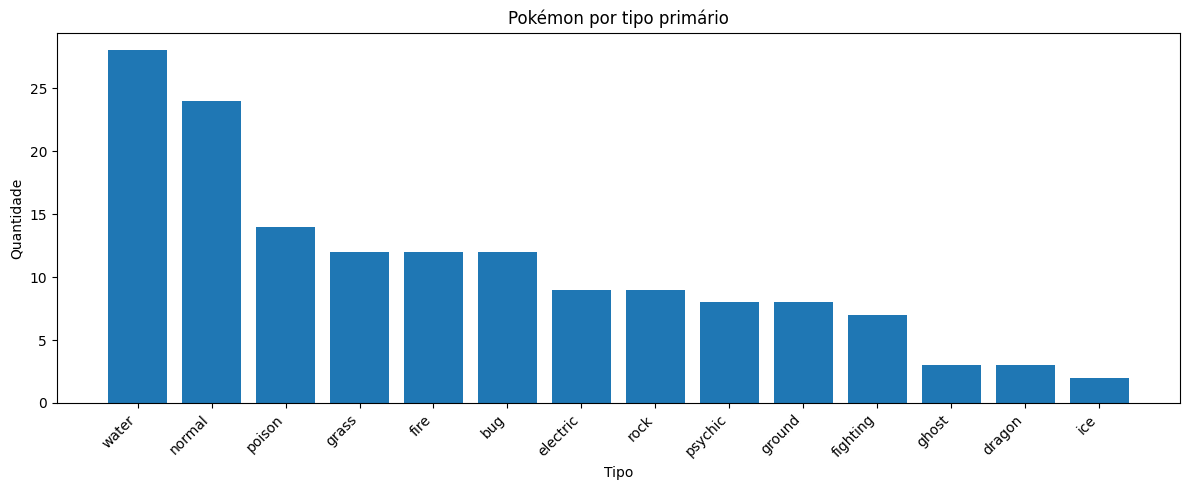

In [28]:
type_counts = metadata["primary_type"].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Pokémon por tipo primário")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 15 maiores documentos do corpus

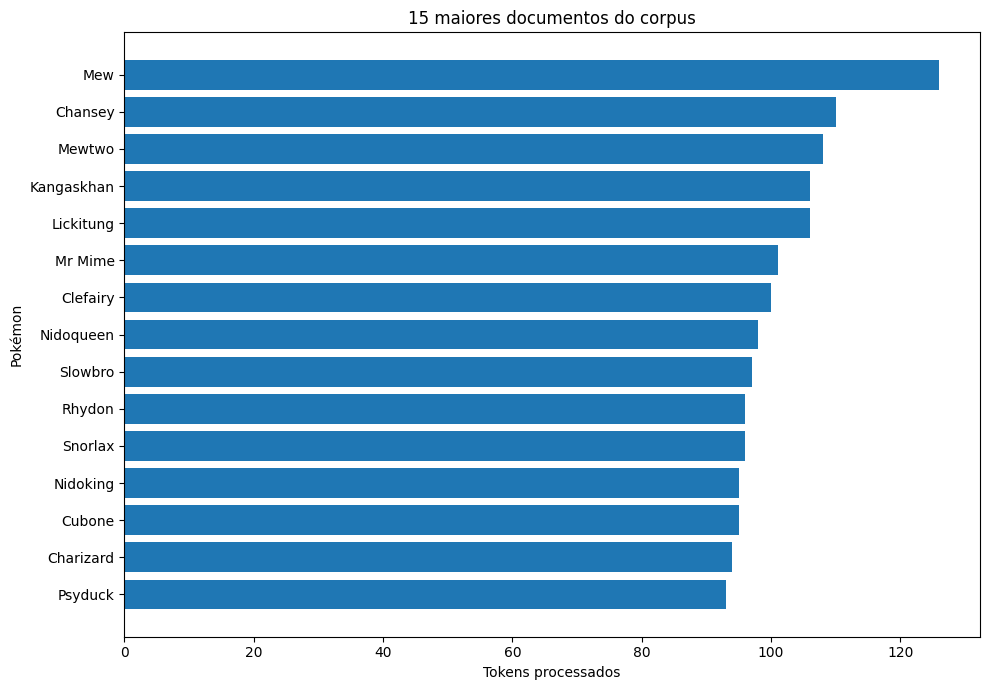

In [29]:
largest_docs = (
    metadata
    .nlargest(15, "processed_tokens")
    .sort_values("processed_tokens")
)

plt.figure(figsize=(10, 7))
plt.barh(
    largest_docs["name"],
    largest_docs["processed_tokens"]
)
plt.title("15 maiores documentos do corpus")
plt.xlabel("Tokens processados")
plt.ylabel("Pokémon")
plt.tight_layout()
plt.show()

### Crescimento das features com N-grams

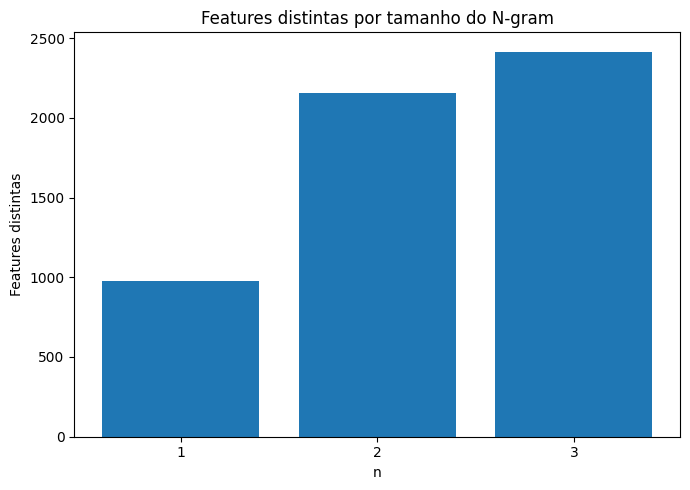

In [30]:
plt.figure(figsize=(7, 5))
plt.bar(
    df_ngram_stats["n"].astype(str),
    df_ngram_stats["features_distintas"]
)
plt.title("Features distintas por tamanho do N-gram")
plt.xlabel("n")
plt.ylabel("Features distintas")
plt.tight_layout()
plt.show()

### Comparação da busca literal com Bag of Words

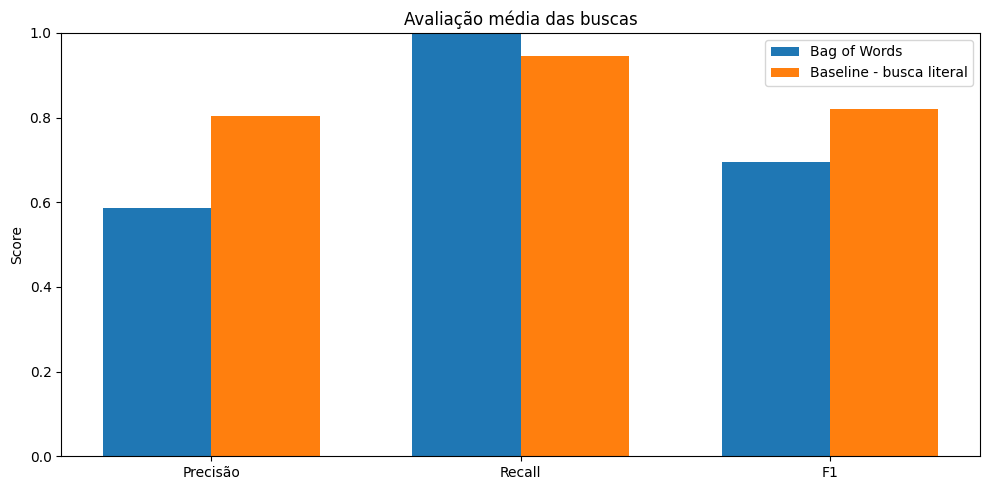

In [31]:
plot_eval = evaluation_summary.set_index("metodo")

x = np.arange(3)
width = 0.35
metrics = ["precision", "recall", "f1"]

plt.figure(figsize=(10, 5))

for i, method in enumerate(plot_eval.index):
    offset = (i - 0.5) * width
    plt.bar(
        x + offset,
        plot_eval.loc[method, metrics],
        width,
        label=method
    )

plt.xticks(x, ["Precisão", "Recall", "F1"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Avaliação média das buscas")
plt.legend()
plt.tight_layout()
plt.show()

### F1 por consulta: Literal × BoW

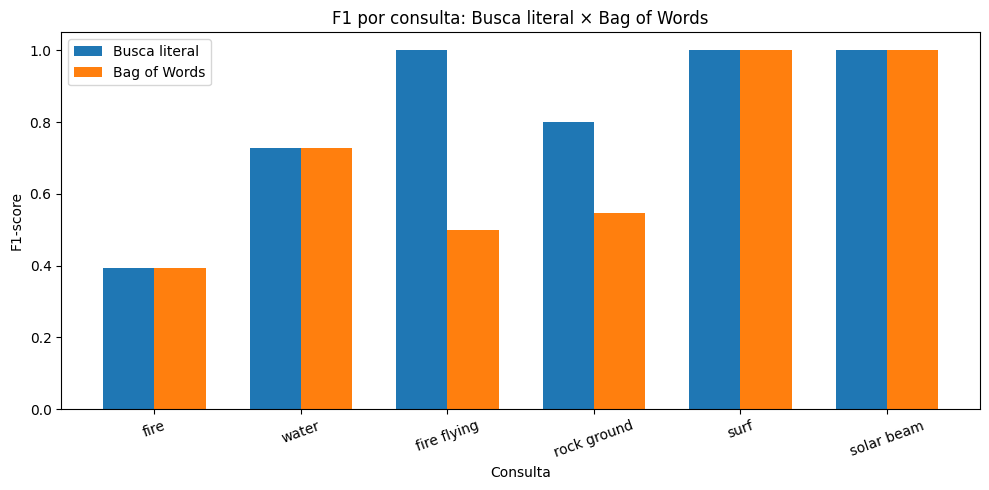

In [32]:
queries = evaluation["query"].unique()

literal_f1 = (
    evaluation[evaluation["metodo"] == "Baseline - busca literal"]
    .set_index("query")
    .loc[queries, "f1"]
)

bow_f1 = (
    evaluation[evaluation["metodo"] == "Bag of Words"]
    .set_index("query")
    .loc[queries, "f1"]
)

x = np.arange(len(queries))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    literal_f1,
    width,
    label="Busca literal"
)

plt.bar(
    x + width / 2,
    bow_f1,
    width,
    label="Bag of Words"
)

plt.xticks(x, queries, rotation=20)
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.xlabel("Consulta")
plt.title("F1 por consulta: Busca literal × Bag of Words")
plt.legend()

plt.tight_layout()
plt.show()

# Vieses e limitações

O corpus e a avaliação foram construídos para um recorte específico e, portanto, os resultados devem ser interpretados dentro desse contexto.

- **Domínio e seleção:** o corpus é especializado no universo Pokémon e contém apenas os 151 Pokémon de Kanto. Portanto, os resultados não podem ser generalizados para linguagem geral, outras gerações ou outros domínios.

- **Fonte e versão:** os dados dependem exclusivamente da PokéAPI. Embora o corpus seja orientado ao contexto de FireRed, nem todos os atributos disponibilizados pela API são específicos dessa versão. Assim, o conjunto não representa integralmente o banco de dados interno do jogo.

- **Construção dos documentos:** os documentos combinam descrições em linguagem natural com atributos estruturados, como tipos e golpes. Essa estrutura favorece consultas lexicais diretamente relacionadas a esses campos.

- **Avaliação:** os conjuntos de relevância são derivados dos próprios metadados da PokéAPI, tornando a avaliação objetiva e reproduzível, porém mais adequada a consultas factuais e lexicais do que a consultas subjetivas ou semânticas.

- **Busca e pré-processamento:** a busca é lexical e depende dos termos presentes no corpus, não tratando automaticamente sinônimos, significados implícitos ou ambiguidades. A lematização é aplicada apenas às descrições, enquanto termos específicos do domínio são preservados.

- **N-grams:** com apenas 151 documentos e descrições curtas, sequências maiores tornam-se rapidamente específicas e esparsas. Por isso, os N-grams foram utilizados apenas como análise exploratória.

Dessa forma, os resultados representam o comportamento de um experimento de busca textual sobre um corpus especializado e estruturado, não podendo ser diretamente generalizados para corpora maiores, textos livres ou buscas semânticas.